<a href="https://colab.research.google.com/github/ibarra-fernando/Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion/blob/main/notebooks/Practicas/practica_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clase 2 - Manipulación de datos organizacionales y visualización**

In [2]:
#Importamos las librerías que vamos a utilizar
import numpy as np #para hacer operaciones matemáticas
import pandas as pd #para manejo de archivos de datos
import matplotlib.pyplot as plt #para hacer gráficos
import seaborn as sns #para hacer gráficos

In [3]:
# Armamos una matriz que contenga datos de producción (en unidades)

matriz_produccion = np.array([
    [150, 200, 100],  # Planta Norte
    [180, 150, 120],  # Planta Centro
    [90, 110, 130]    # Planta Sur
])
print(matriz_produccion)

[[150 200 100]
 [180 150 120]
 [ 90 110 130]]


In [6]:
# Ahora la convertimos en una tabla de datos con las etiquetas correspondientes

data_produccion = pd.DataFrame(
    matriz_produccion,
    index=["Planta Norte", "Planta Centro", "Planta Sur"],
    columns=["Producto A", "Producto B", "Producto C"]
)
data_produccion

,Producto A,Producto B,Producto C
Planta Norte,150,200,100
Planta Centro,180,150,120
Planta Sur,90,110,130


In [7]:
# Agregamos una columna de producción total por planta
data_produccion["Total Unidades"] = data_produccion.sum(axis=1)
data_produccion

,Producto A,Producto B,Producto C,Total Unidades
Planta Norte,150,200,100,450
Planta Centro,180,150,120,450
Planta Sur,90,110,130,330


In [10]:
#Armamos una tabla que contenga los porcentajes de contribución de cada producto
data_porcentaje = data_produccion.div(data_produccion["Total Unidades"], axis=0) * 100
data_porcentaje

,Producto A,Producto B,Producto C,Total Unidades
Planta Norte,33.333333,44.444444,22.222222,100.0
Planta Centro,40.000000,33.333333,26.666667,100.0
Planta Sur,27.272727,33.333333,39.393939,100.0


In [11]:
# Calculamos los totales por producto
total_producto_A = data_produccion["Producto A"].sum()
total_producto_B = data_produccion["Producto B"].sum()
total_producto_C = data_produccion["Producto C"].sum()

print("Totales por Producto:")
print("Producto A:", total_producto_A)
print("Producto B:", total_producto_B)
print("Producto C:", total_producto_C)
print("Total Unidades:", data_produccion["Total Unidades"].sum())

Totales por Producto:
Producto A: 420
Producto B: 460
Producto C: 350
Total Unidades: 1230


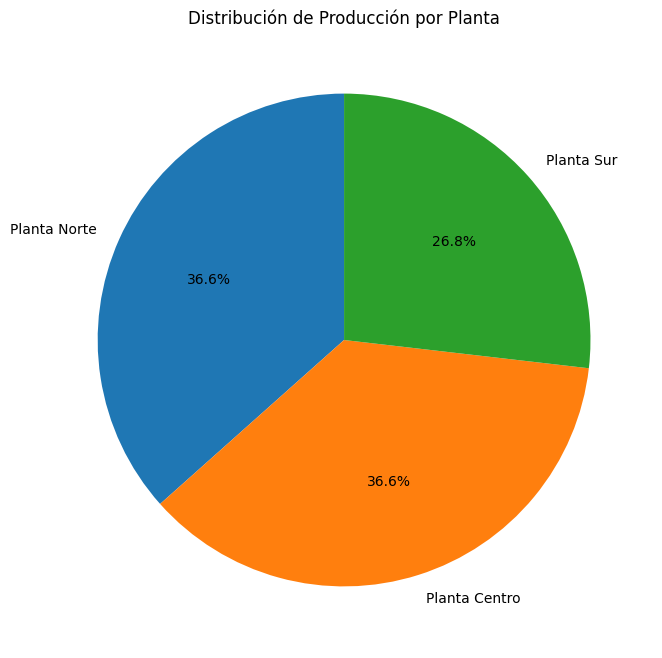

In [21]:
#Gráfico 1 - Visualizamos como se distribuye porcentualmente la producción respecto de cada  de cada planta
#Para esto hacemos un gráfico de torta
plt.figure(figsize=(8, 8))
plt.pie(data_produccion["Total Unidades"], labels=data_produccion.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribución de Producción por Planta")
plt.show()

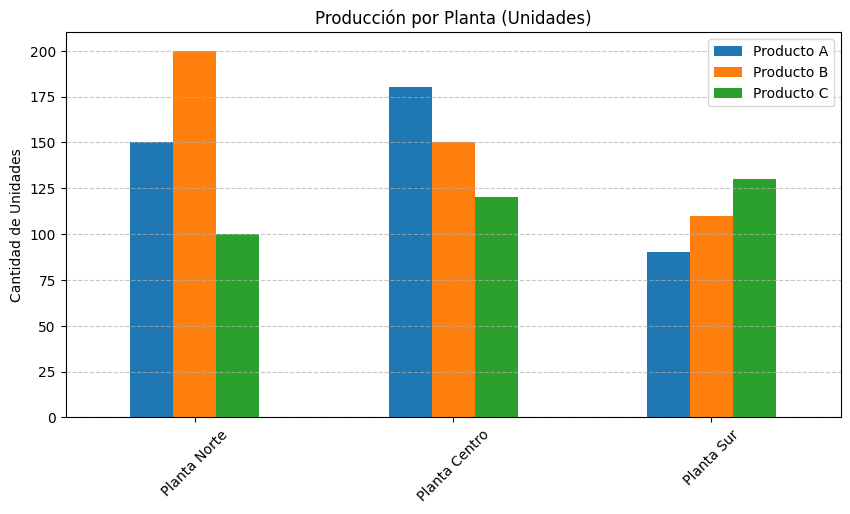

In [35]:
from matplotlib.typing import LineStyleType
#Gráfico 2:Visualizamos la cantidad en unidades de producción de cada producto en cada planta
#Para esto hacemos un gráfico de barras
plt.figure(figsize=(10, 5))
data_produccion.loc[:, ["Producto A","Producto B","Producto C"]].plot(kind='bar', ax=plt.gca())
plt.title("Producción por Planta (Unidades)")
plt.ylabel("Cantidad de Unidades")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

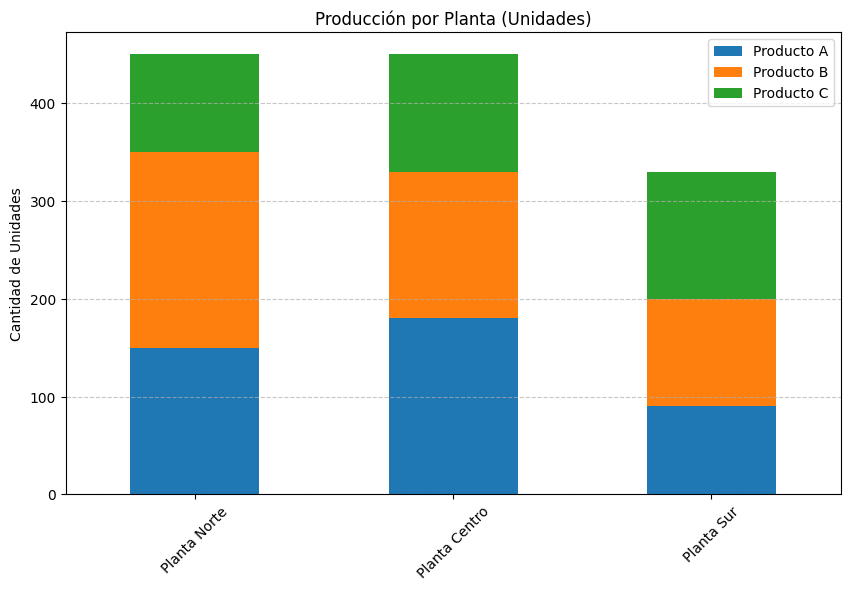

In [38]:
# Gráfico 3: Visualizamos la producción por planta, destacando la cantidad por producto
#Para esto hacemos un gráfico de barras apiladas
plt.figure(figsize=(10, 6))
data_produccion.loc[:, ["Producto A","Producto B","Producto C"]].plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Producción por Planta (Unidades)")
plt.ylabel("Cantidad de Unidades")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

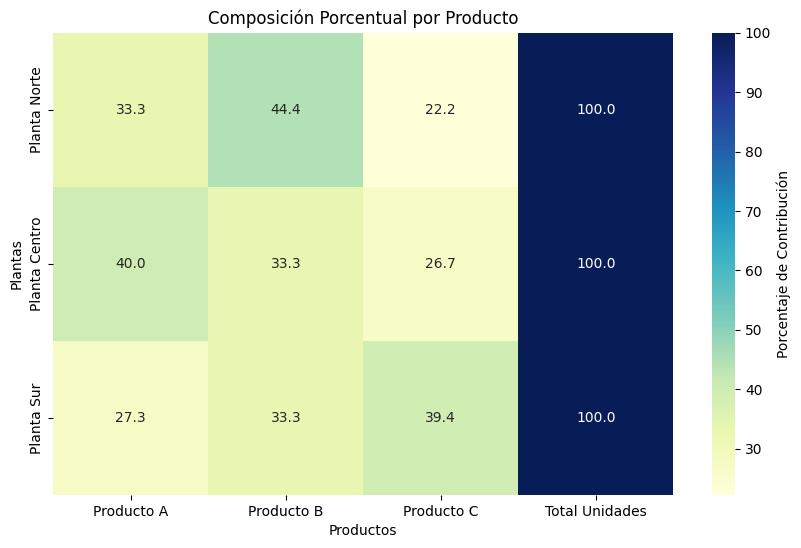

In [37]:
# Gráfico 4: Visualizamos la composición porcentual de cada producto en cada planta
# Para esto hacemos un mapa de calor
plt.figure(figsize=(10, 6))
sns.heatmap(data_porcentaje, annot=True, fmt=".1f", cmap="YlGnBu",
            cbar_kws={'label': 'Porcentaje de Contribución'})
plt.title("Composición Porcentual por Producto")
plt.xlabel("Productos")
plt.ylabel("Plantas")
plt.show()